In [21]:
import pandas as pd
import numpy as np
np.random.seed(42)
n_students = 200

# hours studied between 0 and 20
hours = np.random.randint(0, 15, n_students)
prob_pass = 1 / (1 + np.exp(-( -4 + 0.4*hours )))  # sigmoid curve
passed = np.random.binomial(1, prob_pass)

codecademyU = pd.DataFrame({
    'hours_studied': hours,
    'passed_exam': passed
})
codecademyU.to_csv('codecademyU.csv', index=False)

print(codecademyU.head())


n_students2 = 300
hours2 = np.random.randint(0, 15, n_students2)
practice_test = np.random.randint(0, 2, n_students2)  
# 0 = no practice, 1 = did practice

#Probability depends on both hours and practice
prob_pass2 = 1 / (1 + np.exp(-( -3 + 0.35*hours2 + 1.5*practice_test )))
passed2 = np.random.binomial(1, prob_pass2)

codecademyU2 = pd.DataFrame({
    'hours_studied': hours2,
    'practice_test': practice_test,
    'passed_exam': passed2
})
codecademyU2.to_csv('codecademyU_2.csv', index=False)

print(codecademyU2.head())


   hours_studied  passed_exam
0              6            0
1              3            0
2             12            1
3             14            1
4             10            1
   hours_studied  practice_test  passed_exam
0             12              1            1
1              1              0            0
2             11              0            0
3              9              1            1
4             13              0            1


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [31]:
codecademyU = pd.read_csv('codecademyU.csv')
hours_studied = codecademyU[['hours_studied']]
passed_exam = codecademyU['passed_exam']
model = LogisticRegression()
model.fit(hours_studied, passed_exam)

LogisticRegression()

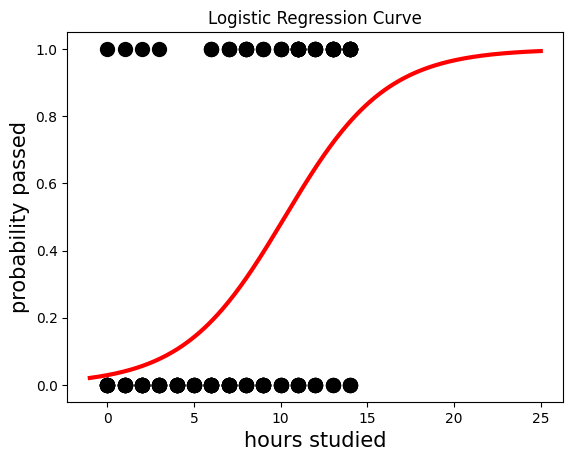

In [32]:
#Probability curve
sample_x = pd.DataFrame(np.linspace(-1, 25, 300), columns=['hours_studied'])
probability = model.predict_proba(sample_x)[:,1]

plt.scatter(hours_studied, passed_exam, color='black', s=100)
plt.plot(sample_x, probability, color='red', linewidth=3)
plt.xlabel('hours studied', fontsize=15)
plt.ylabel('probability passed', fontsize=15)
plt.title('Logistic Regression Curve')
plt.show()

In [33]:
#Estimate probability for 5 hours
five_hour_studier = model.predict_proba(pd.DataFrame([5], columns=['hours_studied']))[:,1][0]
print("Probability of passing with 5 hours studied:", five_hour_studier)

Probability of passing with 5 hours studied: 0.14211088952120718


In [26]:
codecademyU2 = pd.read_csv('codecademyU_2.csv')

X = codecademyU2[['hours_studied', 'practice_test']]
y = codecademyU2.passed_exam

In [27]:
#Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

#Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=27)

#Fit logistic regression
cc_lr = LogisticRegression()
cc_lr.fit(X_train, y_train)

LogisticRegression()

In [28]:
#Intercept and coefficients
print("Intercept:", cc_lr.intercept_)
print("Coefficients:", cc_lr.coef_)

#Predictions
y_pred = cc_lr.predict(X_test)
y_pred_prob = cc_lr.predict_proba(X_test)[:,1]

Intercept: [0.12285489]
Coefficients: [[1.7141285  1.03152502]]


In [29]:
print("Predicted outcomes:", y_pred)
print("Predicted probabilities:", y_pred_prob)
print("True outcomes:", y_test.values)
#Confusion matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Predicted outcomes: [1 0 0 1 1 0 0 1 0 1 1 1 1 0 0 1 1 1 0 0 0 0 0 1 0 1 0 0 0 1 0 1 1 0 0 0 0
 0 0 1 1 0 0 0 1 0 1 0 1 1 0 1 1 0 1 1 1 1 0 0 1 0 1 0 1 0 1 1 0 1 0 0 1 0
 0]
Predicted probabilities: [0.82824532 0.29152251 0.02509667 0.87752359 0.87752359 0.39975801
 0.11146826 0.9721576  0.16877936 0.68597228 0.95918424 0.81572647
 0.98108866 0.15711039 0.02509667 0.81572647 0.9405356  0.87752359
 0.39975801 0.21687958 0.30950881 0.47598979 0.16877936 0.82824532
 0.11146826 0.9405356  0.30950881 0.21687958 0.03683913 0.9721576
 0.49736743 0.82824532 0.68597228 0.23176713 0.39975801 0.3794089
 0.07786079 0.3794089  0.05377271 0.76446183 0.81572647 0.02509667
 0.21687958 0.47598979 0.9721576  0.3794089  0.81572647 0.21687958
 0.66724961 0.95918424 0.21687958 0.59517794 0.87752359 0.16877936
 0.59517794 0.95918424 0.66724961 0.68597228 0.47598979 0.21687958
 0.57440057 0.11146826 0.74870447 0.21687958 0.57440057 0.39975801
 0.98108866 0.68597228 0.39975801 0.59517794 0.11146826 0.3794089


In [30]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.72
Precision: 0.8285714285714286
Recall: 0.6590909090909091
F1 Score: 0.7341772151898734
